### The following Script Contains:
#### 1. Import Libraries and Data¶
#### 2. Preprocessing: Cleaning, Wrangling, Reshaping and Splitting the Data
#### 3. Hyperparameter Tuning with Bayesian Optimization
#### 4. Building the CNN Model with Optimized Hyperparameters

### 1. Import Libraries and Data

In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.metrics import multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix as sklearn_confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.multiclass import type_of_target
import tensorflow as tf
from numpy import unique
from numpy import reshape
from tensorflow.keras.models import Sequential
from sklearn.model_selection import cross_val_score
from tensorflow.keras.layers import Input, Conv1D, Dense, Dropout, BatchNormalization, Flatten, MaxPooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adadelta, Adagrad, Adamax, Nadam, Ftrl
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from scikeras.wrappers import KerasClassifier  # Use scikeras for scikit-learn compatibility
from math import floor
from bayes_opt import BayesianOptimization
from tensorflow.keras.layers import LeakyReLU  # Use tensorflow.keras instead of keras
LeakyReLU = LeakyReLU(negative_slope=0.1)
import warnings

In [6]:
# Display charts inline in the notebook
%matplotlib inline

In [8]:
# Display max number of columns
pd.set_option('display.max_columns', None)

In [10]:
# Create path
path = r'/Users/asadagha/Documents/CF Data Analytics/Machine Learning/Achievement 2/Data Sets'

In [12]:
# Import datasets
df = pd.read_csv(os.path.join(path, 'Prepared Data', 'weather_cleaned.csv'))
pleasant = pd.read_csv(os.path.join(path, 'Original Data', 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

In [14]:
df.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_cloud_cover,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_cloud_cover,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_cloud_cover,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_cloud_cover,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_pressure,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_cloud_cover,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,SONNBLICK_cloud_cover,SONNBLICK_humidity,SONNBLICK_pressure,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_cloud_cover,STOCKHOLM_humidity,STOCKHOLM_pressure,STOCKHOLM_global_radiation,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,0.81,1.0195,0.88,0.00,7.0,3.7,-0.9,7.9,4,0.67,1.017,0.44,0.01,2.3,2.4,-0.4,5.1,7,0.85,1.0032,0.07,0.25,0.0,9.3,7.4,11.0,8,0.83,1.0161,0.12,0.08,0.0,10.0,7.0,11.5,7,0.91,1.0010,0.13,0.22,0.0,10.6,9.4,8.3,8,0.82,1.0094,0.28,0.48,1.6,7.9,3.9,9.4,8,1.00,1.0173,0.20,0.00,0.0,-0.6,-1.9,0.5,7,0.83,1.0063,0.22,0.32,1.0,9.5,8.5,11.1,6,0.92,1.0260,0.53,0.0,1.4,7.6,4.4,10.8,5,0.67,1.018,0.20,0.10,0.0,6.9,1.1,10.4,8,0.98,0.9978,0.04,1.14,0.0,4.9,3.8,5.9,4,0.73,1.0304,0.48,0.01,2.3,-5.9,-8.5,-3.2,5,0.98,1.0114,0.05,0.32,0.0,4.2,2.2,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,19600102,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,0.84,1.0172,0.25,0.00,0.0,2.9,2.2,4.4,4,0.67,1.017,0.18,0.31,0.0,2.3,1.4,3.1,8,0.90,1.0056,0.14,0.06,0.1,7.7,6.4,8.3,8,0.89,1.0161,0.18,0.66,0.5,8.2,7.4,11.0,7,0.98,1.0051,0.13,0.23,0.0,6.1,3.9,10.6,8,0.86,1.0086,0.12,0.27,0.0,7.7,6.8,9.1,6,0.94,1.0173,0.56,0.13,3.2,2.1,-1.3,5.5,8,0.92,1.0062,0.17,1.34,0.4,8.6,7.5,9.9,7,0.86,1.0254,0.46,0.0,0.9,9.8,7.4,12.2,6,0.72,1.018,0.61,0.30,5.1,6.2,4.2,10.2,8,0.62,1.0139,0.04,0.00,0.0,3.4,2.8,4.9,6,0.97,1.0292,0.21,0.61,0.0,-9.5,-10.5,-8.5,5,0.62,1.0114,0.05,0.06,0.0,4.0,3.0,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,19600103,1,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,0.77,1.0179,0.67,0.00,3.5,3.1,-0.5,6.4,4,0.67,1.017,0.30,0

In [16]:
df.shape

(22950, 137)

In [18]:
pleasant.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [20]:
pleasant.shape

(22950, 16)

### 2. Preprocessing: Cleaning, Wrangling, Reshaping and Splitting the Data

In [24]:
# Drop 'DATE' and 'MONTH' columns from weather dataset
df_2 = df.drop(columns=['DATE', 'MONTH'])

In [26]:
# Check shape
df_2.shape

(22950, 135)

In [28]:
df_2.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_cloud_cover,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_cloud_cover,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_cloud_cover,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_cloud_cover,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_pressure,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_cloud_cover,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,SONNBLICK_cloud_cover,SONNBLICK_humidity,SONNBLICK_pressure,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_cloud_cover,STOCKHOLM_humidity,STOCKHOLM_pressure,STOCKHOLM_global_radiation,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,0.81,1.0195,0.88,0.00,7.0,3.7,-0.9,7.9,4,0.67,1.017,0.44,0.01,2.3,2.4,-0.4,5.1,7,0.85,1.0032,0.07,0.25,0.0,9.3,7.4,11.0,8,0.83,1.0161,0.12,0.08,0.0,10.0,7.0,11.5,7,0.91,1.0010,0.13,0.22,0.0,10.6,9.4,8.3,8,0.82,1.0094,0.28,0.48,1.6,7.9,3.9,9.4,8,1.00,1.0173,0.20,0.00,0.0,-0.6,-1.9,0.5,7,0.83,1.0063,0.22,0.32,1.0,9.5,8.5,11.1,6,0.92,1.0260,0.53,0.0,1.4,7.6,4.4,10.8,5,0.67,1.018,0.20,0.10,0.0,6.9,1.1,10.4,8,0.98,0.9978,0.04,1.14,0.0,4.9,3.8,5.9,4,0.73,1.0304,0.48,0.01,2.3,-5.9,-8.5,-3.2,5,0.98,1.0114,0.05,0.32,0.0,4.2,2.2,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,0.84,1.0172,0.25,0.00,0.0,2.9,2.2,4.4,4,0.67,1.017,0.18,0.31,0.0,2.3,1.4,3.1,8,0.90,1.0056,0.14,0.06,0.1,7.7,6.4,8.3,8,0.89,1.0161,0.18,0.66,0.5,8.2,7.4,11.0,7,0.98,1.0051,0.13,0.23,0.0,6.1,3.9,10.6,8,0.86,1.0086,0.12,0.27,0.0,7.7,6.8,9.1,6,0.94,1.0173,0.56,0.13,3.2,2.1,-1.3,5.5,8,0.92,1.0062,0.17,1.34,0.4,8.6,7.5,9.9,7,0.86,1.0254,0.46,0.0,0.9,9.8,7.4,12.2,6,0.72,1.018,0.61,0.30,5.1,6.2,4.2,10.2,8,0.62,1.0139,0.04,0.00,0.0,3.4,2.8,4.9,6,0.97,1.0292,0.21,0.61,0.0,-9.5,-10.5,-8.5,5,0.62,1.0114,0.05,0.06,0.0,4.0,3.0,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,0.77,1.0179,0.67,0.00,3.5,3.1,-0.5,6.4,4,0.67,1.017,0.30,0.00,0.6,2.7,1.7,5.3,6,0.92,1.0165,0.28,0.01,

In [30]:
# Drop 'DATE' column from pleasant dataset
df_pleasant = pleasant.drop(columns=['DATE'])

In [32]:
# Check shape
df_pleasant.shape

(22950, 15)

**Reshaping the Data**

In [35]:
# Create matrices
X = df_2
y = df_pleasant

In [37]:
# Check shapes
print(X.shape)
print(y.shape)

(22950, 135)
(22950, 15)


In [39]:
# Create matrices
X = X.to_numpy()
print(X.shape)

(22950, 135)


In [41]:
# Reshape X to (22950, 15, 9)
X = X.reshape(-1, 15, 9)
print(X.shape)

(22950, 15, 9)


In [43]:
y = np.array(y)

In [45]:
# Reshape y to (22950,)
y = np.argmax(y, axis=1)
print("y shape after argmax:", y.shape)

y shape after argmax: (22950,)


In [47]:
# Check unique values in yto ensure it's correct
print("Unique values in y:", np.unique(y))

Unique values in y: [ 0  1  2  3  4  5  6  7  8  9 10 11 13 14]


In [49]:
# Check shape
y.shape

(22950,)

**Splitting the Data**

In [52]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=127)

In [54]:
type_of_target(y)

'multiclass'

In [56]:
# Determine the number of time steps for the input data
timesteps = X_train.shape[1]

# Determine the dimensionality of the input data
input_dim = X_train.shape[2]

# Specify the number of classes for the target variable
n_classes = 15  

# Create a scorer for accuracy
score_acc = make_scorer(accuracy_score)

In [58]:
# Create function
def bay_area(neurons, activation, kernel, optimizer, learning_rate, batch_size, epochs, layers1, layers2, normalization, dropout, dropout_rate):
    optimizerL = ['SGD', 'Adam', 'RMSprop', 'Adadelta', 'Adagrad', 'Adamax', 'Nadam', 'Ftrl', 'SGD']
    activationL = ['relu', 'sigmoid', 'softplus', 'softsign', 'tanh', 'selu', 'elu', 'exponential', LeakyReLU, 'relu']
    
    neurons = round(neurons)
    kernel = round(kernel)
    activation = activationL[round(activation)]
    optimizer_name = optimizerL[round(optimizer)]
    batch_size = round(batch_size)
    epochs = round(epochs)
    layers1 = round(layers1)
    layers2 = round(layers2)

    def cnn_model():
        model = Sequential()
        model.add(Input(shape=(timesteps, input_dim)))
        model.add(Conv1D(neurons, kernel_size=kernel, activation=activation))
        if normalization > 0.5:
            model.add(BatchNormalization())
        for i in range(layers1):
            model.add(Dense(neurons, activation=activation))
        if dropout > 0.5:
            model.add(Dropout(dropout_rate, seed=127))
        for i in range(layers2):
            model.add(Dense(neurons, activation=activation))
        model.add(MaxPooling1D())
        model.add(Flatten())
        model.add(Dense(n_classes, activation='softmax'))  # sigmoid softmax
        
        # Create a new optimizer instance for each iteration
        if optimizer_name == 'Adam':
            optimizer_instance = Adam(learning_rate=learning_rate)
        elif optimizer_name == 'SGD':
            optimizer_instance = SGD(learning_rate=learning_rate)
        elif optimizer_name == 'RMSprop':
            optimizer_instance = RMSprop(learning_rate=learning_rate)
        elif optimizer_name == 'Adadelta':
            optimizer_instance = Adadelta(learning_rate=learning_rate)
        elif optimizer_name == 'Adagrad':
            optimizer_instance = Adagrad(learning_rate=learning_rate)
        elif optimizer_name == 'Adamax':
            optimizer_instance = Adamax(learning_rate=learning_rate)
        elif optimizer_name == 'Nadam':
            optimizer_instance = Nadam(learning_rate=learning_rate)
        elif optimizer_name == 'Ftrl':
            optimizer_instance = Ftrl(learning_rate=learning_rate)
        
        model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer_instance, metrics=['accuracy'])
        return model

    # K-fold cross-validation
    es = EarlyStopping(monitor='accuracy', mode='max', verbose=1, patience=20)
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=127)
    results = []
    for train, test in kfold.split(X, y):
        model = cnn_model()
        model.fit(X[train], y[train], epochs=epochs, batch_size=batch_size, verbose=0, callbacks=[es])
        scores = model.evaluate(X[test], y[test], verbose=1)
        results.append(scores[1])  # Assuming accuracy is the second metric
    return np.mean(results)

In [60]:
# Start timing the Bayesian Optimization process
start = time.time()

# Define the hyperparameter space for Bayesian Optimization
params = {
    'neurons': (10, 100),
    'kernel': (1, 3),
    'activation': (0, 9),  # 9
    'optimizer': (0, 7),  # 7
    'learning_rate': (0.001, 1),
    'batch_size': (200, 1000), #(10, 50), #
    'epochs': (20, 100),
    'layers1': (1, 3),
    'layers2': (1, 3),
    'normalization': (0, 1),
    'dropout': (0, 1),
    'dropout_rate': (0.3, 0.5)
}

# Run Bayesian Optimization
nn_opt = BayesianOptimization(bay_area, params, random_state=127)
nn_opt.maximize(init_points=15, n_iter=4)  # 25
print('Search took %s minutes' % ((time.time() - start)/60))

|   iter    |  target   |  neurons  |  kernel   | activa... | optimizer | learni... | batch_... |  epochs   |  layers1  |  layers2  | normal... |  dropout  | dropou... |
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Epoch 22: early stopping
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6451 - loss: 1.0188
Epoch 22: early stopping
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6552 - loss: 1.1418
Epoch 22: early stopping
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6382 - loss: 1.0503  
Epoch 22: early stopping
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6617 - loss: 1.1291
Epoch 22: early stopping
144/144 ━━━━━━━━━━━━━━━━━━━━ 0s 958us/step - accuracy: 0.6544 - loss: 1.1381
| 2         | 0.6405664 | 57.144998 | 1.0799259 | 1.6736878 | 5.4095345 | 0.5525967 | 269.02151 | 55.311580 | 2.4310983 | 2.3411063 | 0.4728456 | 0.9061609 

In [62]:
best_params = nn_opt.max['params']
best_score = nn_opt.max['target']

print(f"Best Parameters: {best_params}")
print(f"Highest Accuracy: {best_score}")

Best Parameters: {'neurons': 38.44323212883419, 'kernel': 1.421665899481417, 'activation': 5.983679565752535, 'optimizer': 3.0006634149361586, 'learning_rate': 0.1643203915454267, 'batch_size': 576.474049086029, 'epochs': 99.04569757754855, 'layers1': 2.461802483504723, 'layers2': 1.916037132065908, 'normalization': 0.8550632065684343, 'dropout': 0.3918121345131891, 'dropout_rate': 0.4364036667986773}
Highest Accuracy: 0.9149891138076782


In [64]:
# Retrieve the best parameters from the optimization result
optimum = nn_opt.max['params']

# Assign the best parameters to their respective variables
learning_rate = optimum['learning_rate']
activationL = ['relu', 'sigmoid', 'softplus', 'softsign', 'tanh', 'selu', 'elu', 'exponential', 'LeakyReLU', 'relu']
activation = activationL[round(optimum['activation'])]

# Convert the hyperparameters to their integer form where necessary
optimum['batch_size'] = round(optimum['batch_size'])
optimum['epochs'] = round(optimum['epochs'])
optimum['layers1'] = round(optimum['layers1'])
optimum['layers2'] = round(optimum['layers2'])
optimum['neurons'] = round(optimum['neurons'])
optimum['kernel'] = round(optimum['kernel'])

optimizerL = ['SGD', 'Adam', 'RMSprop', 'Adadelta', 'Adagrad', 'Adamax', 'Nadam', 'Ftrl']
optimizerD = {
    'SGD': SGD(learning_rate=learning_rate),
    'Adam': Adam(learning_rate=learning_rate),
    'RMSprop': RMSprop(learning_rate=learning_rate),
    'Adadelta': Adadelta(learning_rate=learning_rate),
    'Adagrad': Adagrad(learning_rate=learning_rate),
    'Adamax': Adamax(learning_rate=learning_rate),
    'Nadam': Nadam(learning_rate=learning_rate),
    'Ftrl': Ftrl(learning_rate=learning_rate)
}

# Retrieve the optimizer name
optimizer_name = optimizerL[round(optimum['optimizer'])]

# Print the optimum parameters in a readable format
print(f"Best Parameters: ")
print(f"Activation: {activation}")
print(f"Batch Size: {optimum['batch_size']}")
print(f"Dropout Rate: {optimum['dropout_rate']:.4f}")
print(f"Epochs: {optimum['epochs']}")
print(f"Kernel Size: {optimum['kernel']}")
print(f"Layers1: {optimum['layers1']}")
print(f"Layers2: {optimum['layers2']}")
print(f"Learning Rate: {optimum['learning_rate']:.4f}")
print(f"Neurons: {optimum['neurons']}")
print(f"Normalization: {optimum['normalization']:.4f}")
print(f"Optimizer: {optimizer_name}")

Best Parameters: 
Activation: elu
Batch Size: 576
Dropout Rate: 0.4364
Epochs: 99
Kernel Size: 1
Layers1: 2
Layers2: 2
Learning Rate: 0.1643
Neurons: 38
Normalization: 0.8551
Optimizer: Adadelta


### 4. Building the CNN Model with Optimized Hyperparameters

In [67]:
# Best parameters from optimization
best_params = {
    'neurons': 13,
    'kernel': 3,
    'activation': 'softsign',
    'optimizer': 'Adam',
    'learning_rate': 0.0615,
    'batch_size': 858,
    'epochs':60,
    'layers1': 2,
    'layers2': 2,
    'normalization': 0.4579,
    'dropout': 0.40228837505867143,
    'dropout_rate':  0.3935
}

# Initialize optimizer with learning rate
optimizers = {
    'Adam': Adam(learning_rate=best_params['learning_rate']),
    'SGD': SGD(learning_rate=best_params['learning_rate']),
    'RMSprop': RMSprop(learning_rate=best_params['learning_rate']),
    'Adadelta': Adadelta(learning_rate=best_params['learning_rate']),
    'Adagrad': Adagrad(learning_rate=best_params['learning_rate']),
    'Adamax': Adamax(learning_rate=best_params['learning_rate']),
    'Nadam': Nadam(learning_rate=best_params['learning_rate']),
    'Ftrl': Ftrl(learning_rate=best_params['learning_rate'])
}

optimizer = optimizers[best_params['optimizer']]

timesteps = len(X_train[0])
input_dim = len(X_train[0][0])
#n_classes = len(y_train[0])

model = Sequential()
model.add(Conv1D(best_params['neurons'], kernel_size=best_params['kernel'], activation=best_params['activation'], input_shape=(15,9)))

if best_params['normalization'] > 0.5:
    model.add(BatchNormalization())

for _ in range(best_params['layers1']):
    model.add(Dense(best_params['neurons'], activation=best_params['activation']))

if best_params['dropout'] > 0.5:
    model.add(Dropout(best_params['dropout_rate'], seed=123))

for _ in range(best_params['layers2']):
    model.add(Dense(best_params['neurons'], activation=best_params['activation']))

model.add(MaxPooling1D())
model.add(Flatten())
model.add(Dense(n_classes, activation='softmax')) # sigmoid, tanh, softmax

model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Train the model with the optimized parameters
model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], verbose=2)


Epoch 1/60


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 - 1s - 27ms/step - accuracy: 0.6023 - loss: 1.2722
Epoch 2/60
21/21 - 0s - 4ms/step - accuracy: 0.6300 - loss: 1.0252
Epoch 3/60
21/21 - 0s - 3ms/step - accuracy: 0.6543 - loss: 0.9468
Epoch 4/60
21/21 - 0s - 4ms/step - accuracy: 0.6895 - loss: 0.8765
Epoch 5/60
21/21 - 0s - 3ms/step - accuracy: 0.6770 - loss: 0.8803
Epoch 6/60
21/21 - 0s - 4ms/step - accuracy: 0.7060 - loss: 0.8007
Epoch 7/60
21/21 - 0s - 4ms/step - accuracy: 0.7286 - loss: 0.7456
Epoch 8/60
21/21 - 0s - 4ms/step - accuracy: 0.7246 - loss: 0.7527
Epoch 9/60
21/21 - 0s - 4ms/step - accuracy: 0.7437 - loss: 0.7001
Epoch 10/60
21/21 - 0s - 4ms/step - accuracy: 0.7706 - loss: 0.6575
Epoch 11/60
21/21 - 0s - 4ms/step - accuracy: 0.7739 - loss: 0.6334
Epoch 12/60
21/21 - 0s - 4ms/step - accuracy: 0.7911 - loss: 0.5788
Epoch 13/60
21/21 - 0s - 4ms/step - accuracy: 0.7607 - loss: 0.6846
Epoch 14/60
21/21 - 0s - 4ms/step - accuracy: 0.7573 - loss: 0.6888
Epoch 15/60
21/21 - 0s - 4ms/step - accuracy: 0.7628 - loss: 0.6432

In [69]:
model.summary()

Model: "sequential_95"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_95 (Conv1D)              │ (None, 13, 13)         │           364 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_505 (Dense)               │ (None, 13, 13)         │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_506 (Dense)               │ (None, 13, 13)         │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_507 (Dense)               │ (None, 13, 13)         │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_508 (Dense)               │ (None, 13, 13)         │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_95 (MaxPooling1D) │ (None, 6, 13)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_95 (Flatten)            │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_509 (Dense)               │ (None, 15)             │         1,185 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,833 (26.70 KB)

 Trainable params: 2,277 (8.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,556 (17.80 KB)

In [71]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [73]:
# Assuming X_train and y_train are your input data and labels
# One-hot encode y_train
y_train_one_hot = to_categorical(y_train, num_classes=15)

In [75]:
# Check shapes
print(f'X_train shape: {X_train.shape}')
print(f'y_train_one_hot shape: {y_train_one_hot.shape}')

X_train shape: (17212, 15, 9)
y_train_one_hot shape: (17212, 15)


In [77]:
model.fit(X_train, y_train_one_hot, batch_size=744, epochs=97, verbose=2)

Epoch 1/97
24/24 - 1s - 52ms/step - accuracy: 0.8446 - loss: 0.4322
Epoch 2/97
24/24 - 0s - 3ms/step - accuracy: 0.8589 - loss: 0.4017
Epoch 3/97
24/24 - 0s - 3ms/step - accuracy: 0.8609 - loss: 0.3915
Epoch 4/97
24/24 - 0s - 3ms/step - accuracy: 0.8677 - loss: 0.3830
Epoch 5/97
24/24 - 0s - 3ms/step - accuracy: 0.8694 - loss: 0.3778
Epoch 6/97
24/24 - 0s - 3ms/step - accuracy: 0.8729 - loss: 0.3726
Epoch 7/97
24/24 - 0s - 3ms/step - accuracy: 0.8741 - loss: 0.3695
Epoch 8/97
24/24 - 0s - 3ms/step - accuracy: 0.8760 - loss: 0.3654
Epoch 9/97
24/24 - 0s - 4ms/step - accuracy: 0.8762 - loss: 0.3642
Epoch 10/97
24/24 - 0s - 3ms/step - accuracy: 0.8778 - loss: 0.3612
Epoch 11/97
24/24 - 0s - 3ms/step - accuracy: 0.8790 - loss: 0.3584
Epoch 12/97
24/24 - 0s - 3ms/step - accuracy: 0.8793 - loss: 0.3570
Epoch 13/97
24/24 - 0s - 3ms/step - accuracy: 0.8798 - loss: 0.3563
Epoch 14/97
24/24 - 0s - 3ms/step - accuracy: 0.8801 - loss: 0.3542
Epoch 15/97
24/24 - 0s - 3ms/step - accuracy: 0.8821 - l

In [79]:
# Change this to Weather true/false
stations = {
0: 'BASEL',
1: 'BELGRADE',
2: 'BUDAPEST',
3: 'DEBILT',
4: 'DUSSELDORF',
5: 'HEATHROW',
6: 'KASSEL',
7: 'LJUBLJANA',
8: 'MAASTRICHT',
9: 'MADRID',
10: 'MUNCHENB',
11: 'OSLO',
12: 'SONNBLICK',
13: 'STOCKHOLM',
14: 'VALENTIA'

}

In [81]:
print("Unique classes in y_test:", np.unique(y_test))

Unique classes in y_test: [ 0  1  2  3  4  5  6  7  8  9 10 11 13 14]


In [115]:
def confusion_matrix(y_true, y_pred, stations):
    # Check if y_true and y_pred are one-hot encoded or already class indices
    if y_true.ndim == 1:
        y_true_labels = y_true
    else:
        y_true_labels = np.argmax(y_true, axis=1)
    
    if y_pred.ndim == 1:
        y_pred_labels = y_pred
    else:
        y_pred_labels = np.argmax(y_pred, axis=1)

        # Map numeric labels to activity names
    y_true_series = pd.Series([stations[y] for y in y_true_labels])
    y_pred_series = pd.Series([stations[y] for y in y_pred_labels])
    
    return pd.crosstab(y_true_series, y_pred_series, rownames=['True'], colnames=['Pred'])

In [101]:
# Before making predictions, convert y_test to one-hot format
y_test_one_hot = to_categorical(y_test, num_classes=15)

In [103]:
y_pred = model.predict(X_test)

180/180 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step


In [105]:
# Convert y_test_one_hot back to class labels
y_test_labels = np.argmax(y_test_one_hot, axis=1)

In [107]:
# Manually calculate accuracy
y_pred_labels = np.argmax(y_pred, axis=1)
correct_predictions = np.sum(y_test_labels == y_pred_labels)
total_samples = len(y_test_labels)
accuracy = correct_predictions / total_samples

print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 88.78%


In [109]:
y_pred_labels = np.argmax(y_pred, axis=1)

In [111]:
# Convert y_test_one_hot back to class labels
y_test_labels = np.argmax(y_test_one_hot, axis=1)

In [117]:
cm = confusion_matrix(y_test, y_pred, stations)
print(cm)

Pred        BASEL  BELGRADE  BUDAPEST  DEBILT  DUSSELDORF  HEATHROW  KASSEL  \
True                                                                          
BASEL        3545       111        11       3           2         7       0   
BELGRADE      177       915         3       2           0         0       1   
BUDAPEST       32        46       130      16           0         0       0   
DEBILT         19         4        18      35           0         3       0   
DUSSELDORF      1         1         4       2          12        10       0   
HEATHROW        4         5         4       4           2        66       0   
KASSEL          2         3         2       0           1         1       1   
LJUBLJANA      10         1         1       0           0         3       1   
MAASTRICHT      1         0         0       0           0         1       0   
MADRID          5        22         8       0           0        19       0   
MUNCHENB        9         1         2       0       

In [123]:
# Define function to plot confusion matrices
def plot_confusion_matrices(confusion_matrices, class_labels):
    fig, axes = plt.subplots(3, 5, figsize=(25, 15))  # 3x5 grid for 15 stations
    axes = axes.ravel()  # Flatten the axes array for easy iteration

    for i, (conf_matrix, label) in enumerate(zip(confusion_matrices, class_labels)):
        if conf_matrix.sum() > 0:  # Plot only if the confusion matrix contains data
            sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[i])
            axes[i].set_title(f'Confusion Matrix for {label}')
            axes[i].set_xlabel('Predicted Label')
            axes[i].set_ylabel('True Label')
        else:
            axes[i].axis('off')  # Hide empty subplots

    plt.tight_layout()
    plt.show()

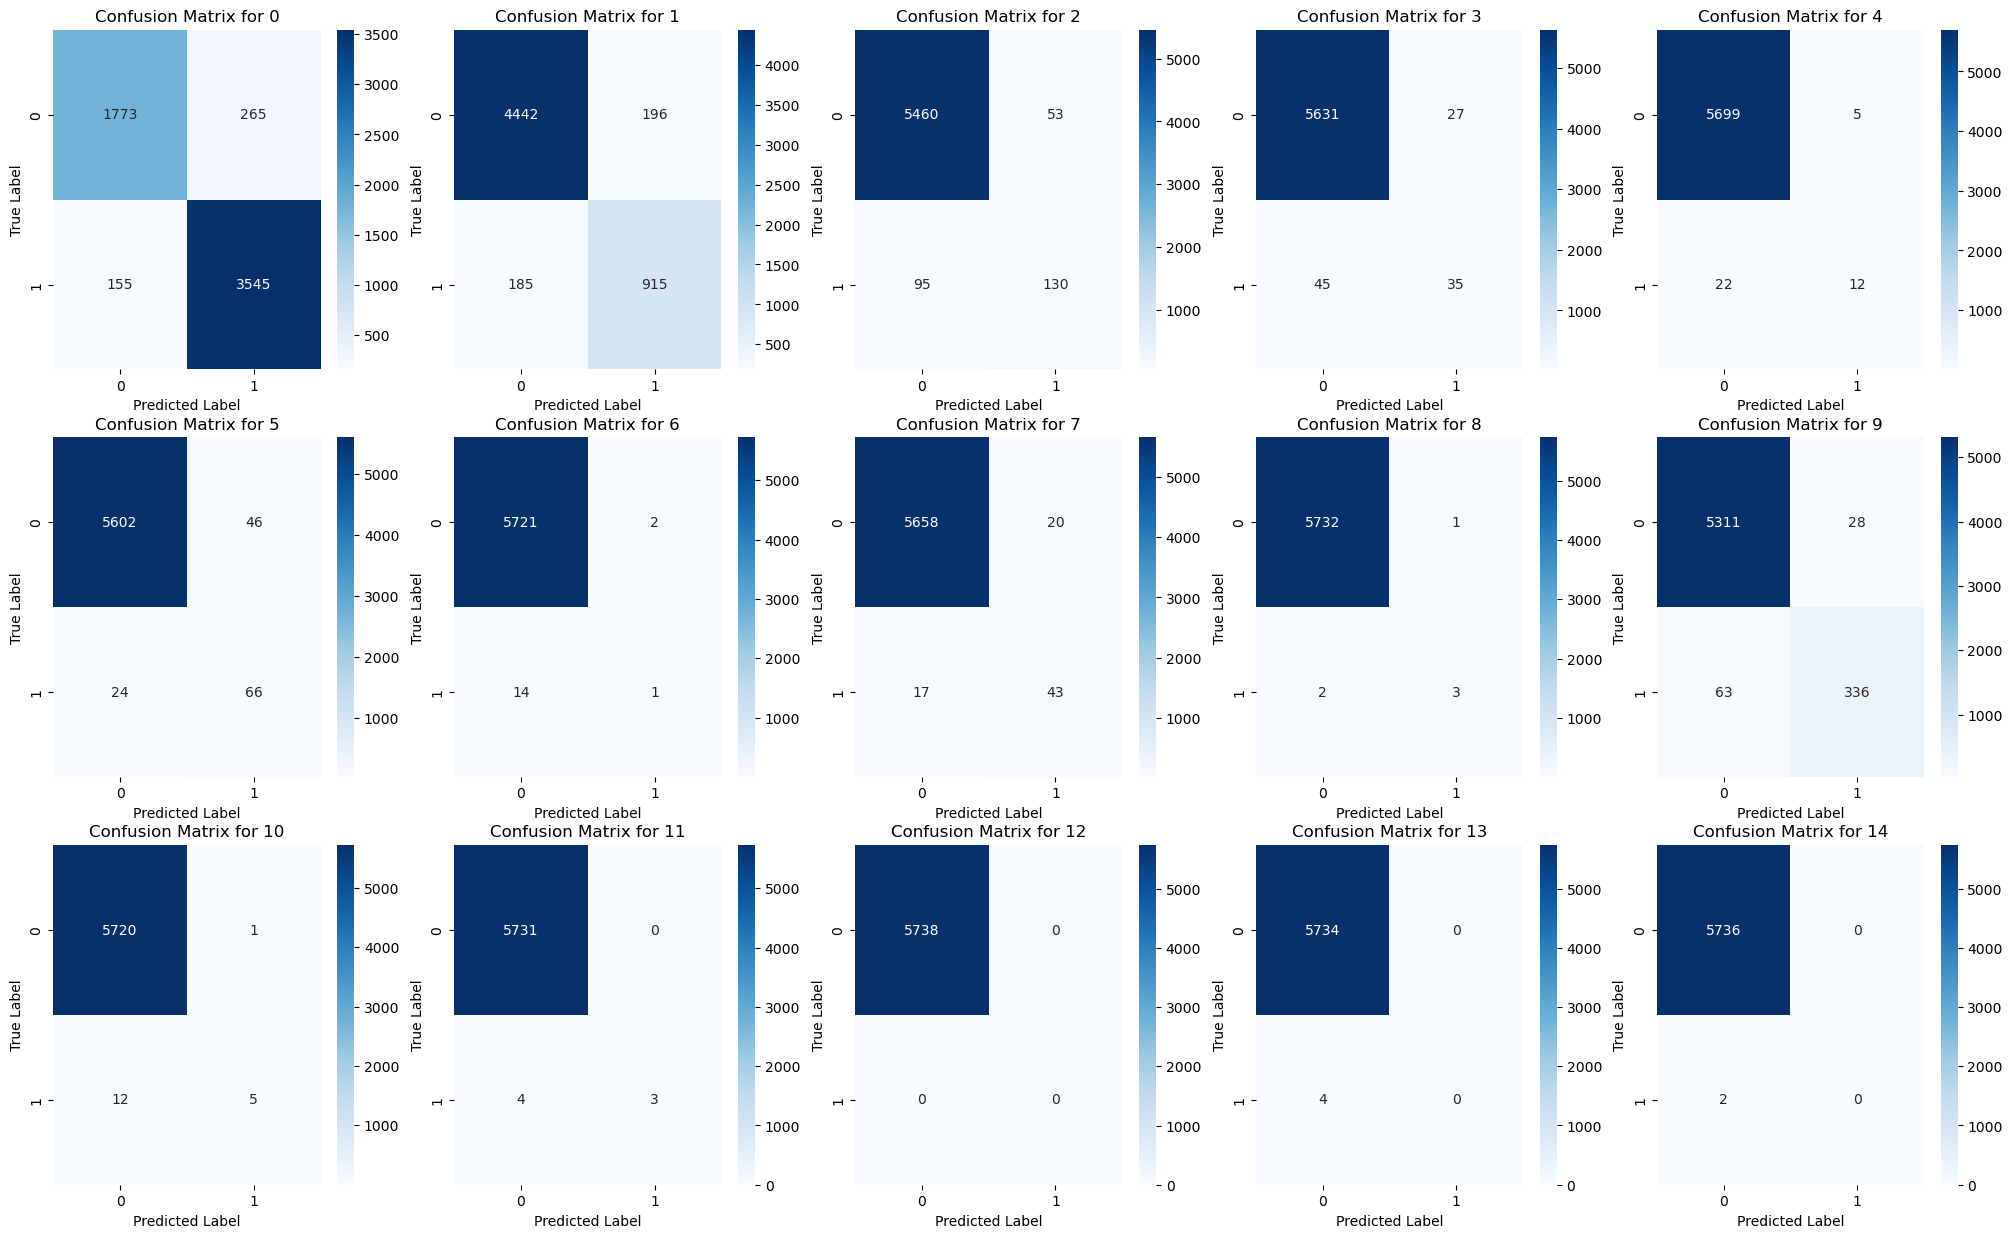

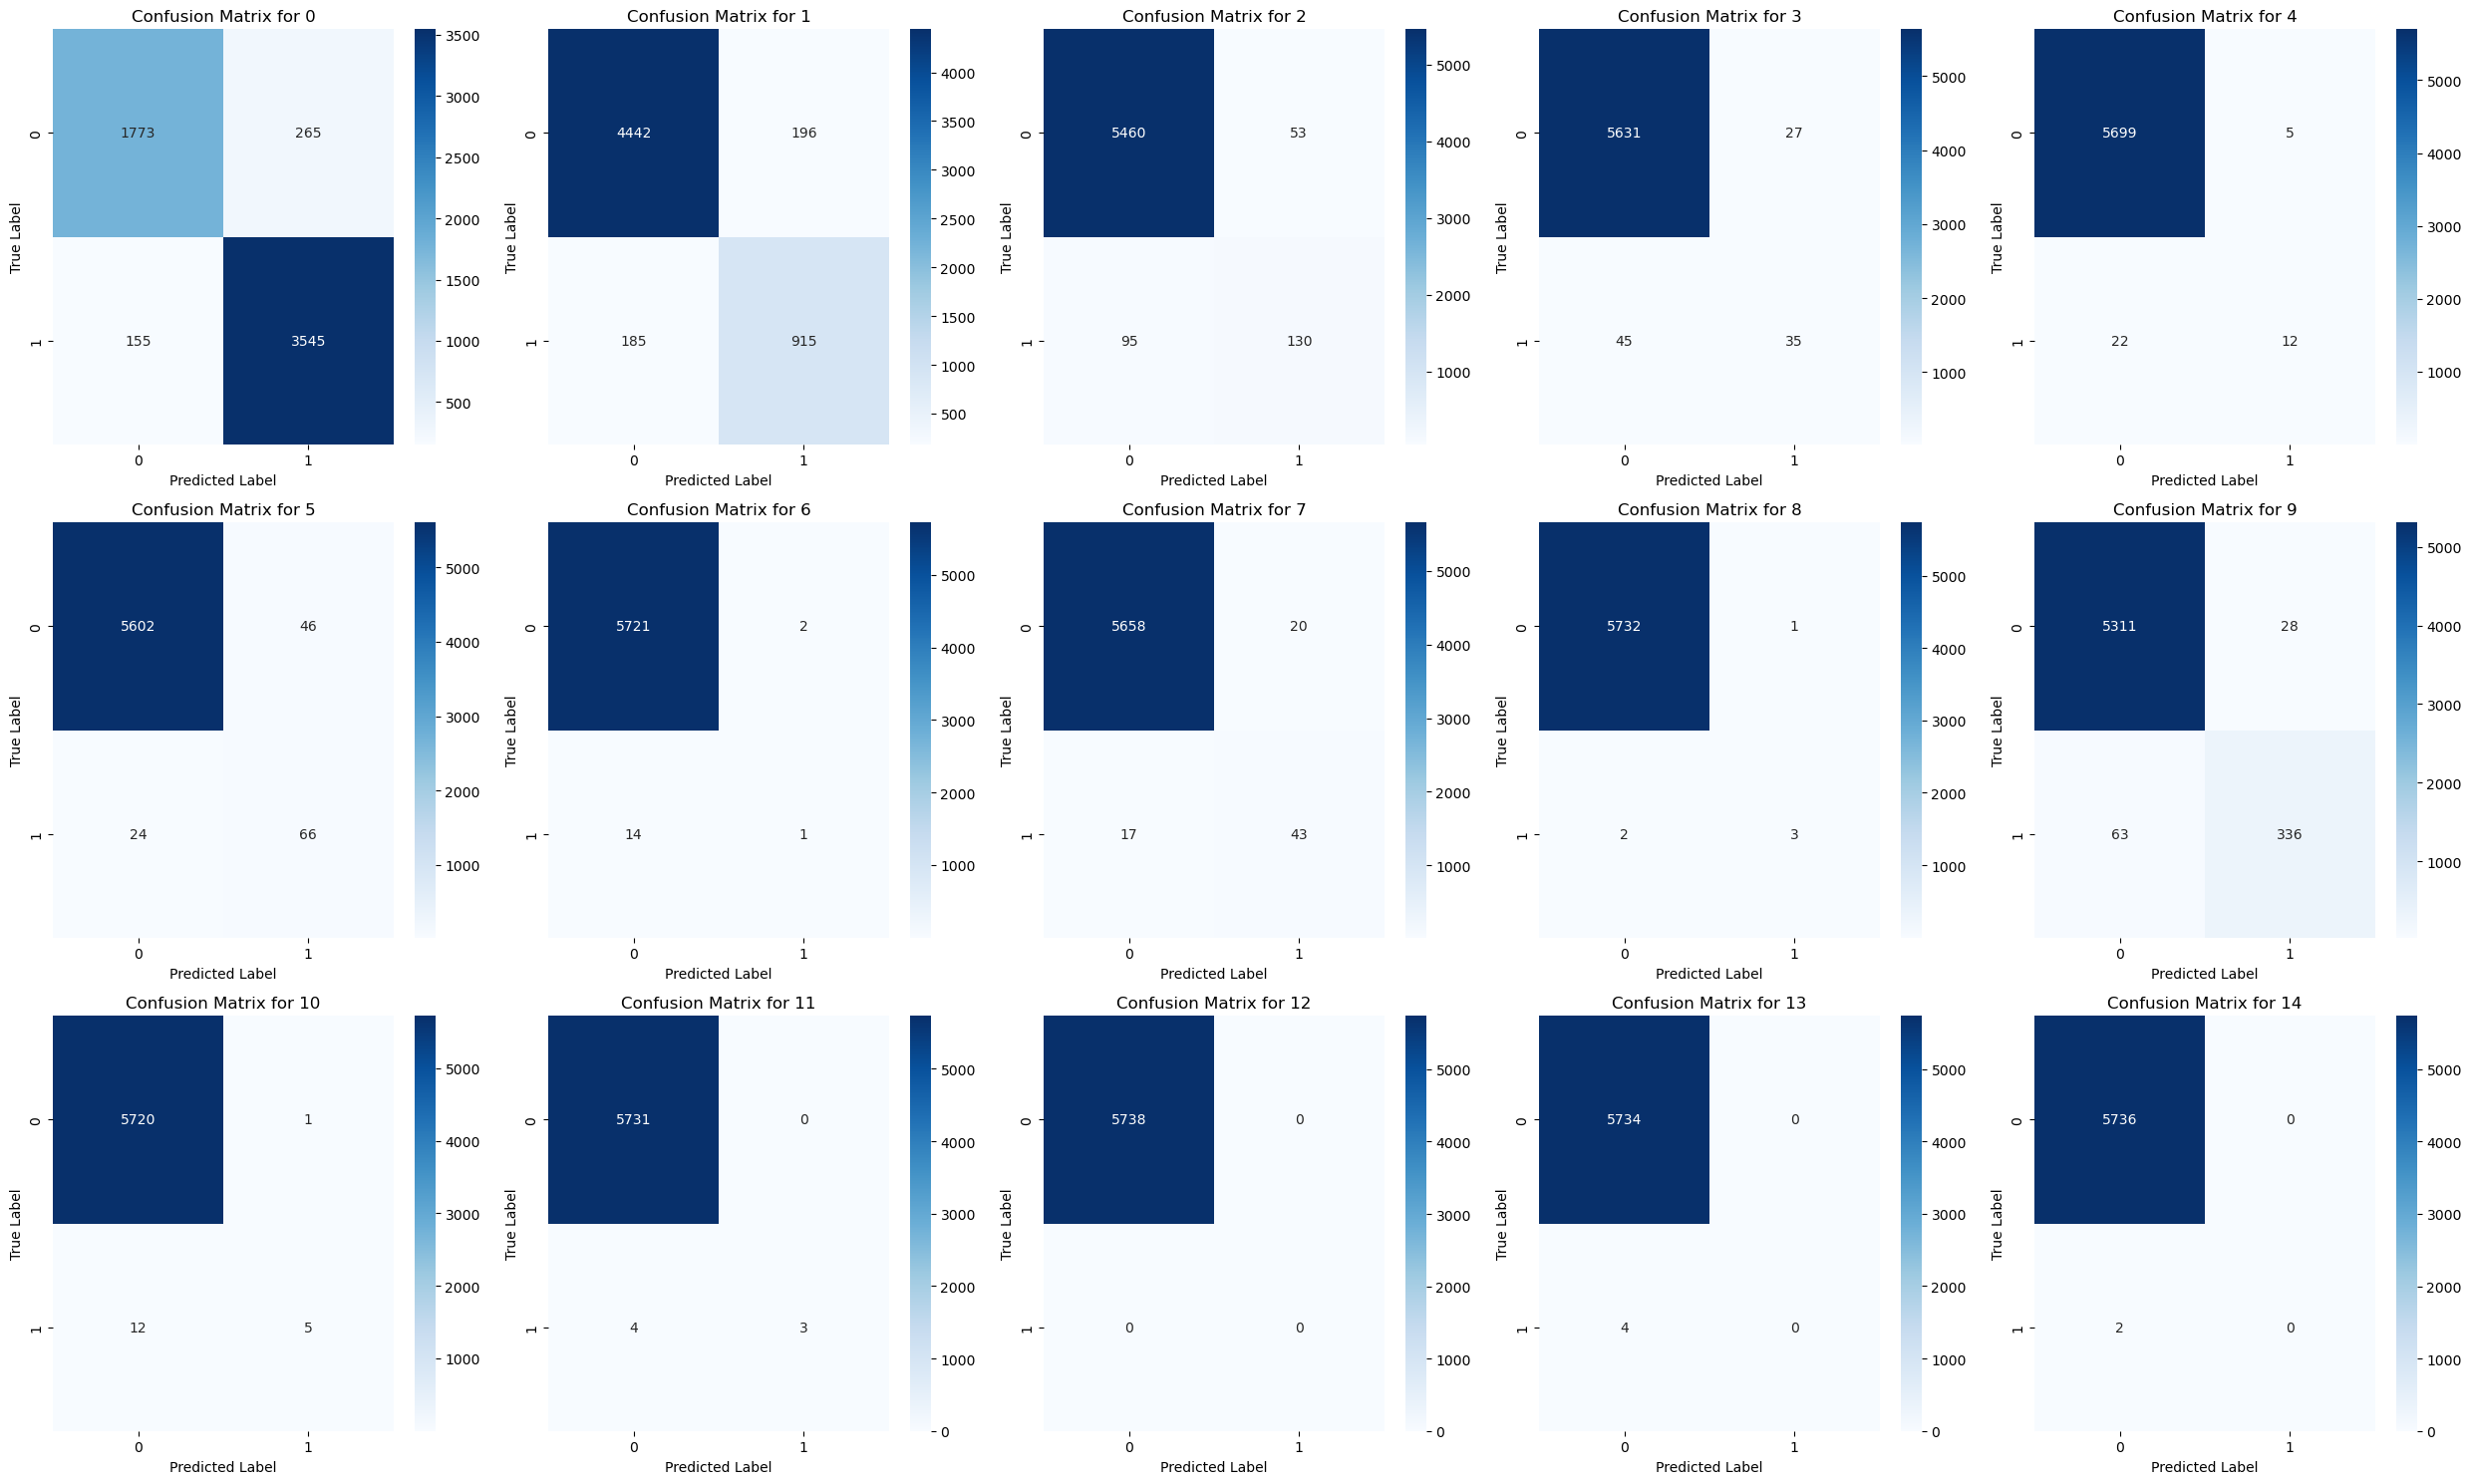

In [125]:
# Generate individual confusion matrices for each station
confusion_matrices = []
for station in stations:
    cm_station = sklearn_confusion_matrix(
        y_test_labels == station,
        y_pred_labels == station,
        labels=[False, True]
    )
    confusion_matrices.append(cm_station)

# Plot the confusion matrices
plot_confusion_matrices(confusion_matrices, stations)